# 12 — Stochastic control (Pontryagin LQR)

Doc page: [stochastic_control.rst](../../docs/source/algorithms/stochastic_control.rst).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Cellule 1 — LQR scalaire et équation de Riccati

**Théorème (Kalman, LQR).** Pour le système $\dot x = ax + bu$ et le
coût
$$J = \int_0^T (q x^2 + r u^2)\,dt + s\,x(T)^2,$$
le contrôle optimal est $u^*(t) = -(b/r)\,P(t)\,x(t)$ où $P(t)$
satisfait la Riccati rétrograde
$$-\dot P = 2aP - (b^2/r) P^2 + q,\qquad P(T) = s.$$

**Équation pivot (cas $a = b = q = r = 1$).** Le point fixe
stationnaire est $P^* = 1 + \sqrt{2} \approx 2.414$.

**Ce que la cellule vérifie.** Le primitive `pontryagin_lqr` retourne
$P(0)$ proche du point fixe pour $T = 5$.


P(0) numérique  = 2.7321
P* analytique   = 2.4142
P(T) (terminal) = 0.5000
Coût optimal    = 2.4701


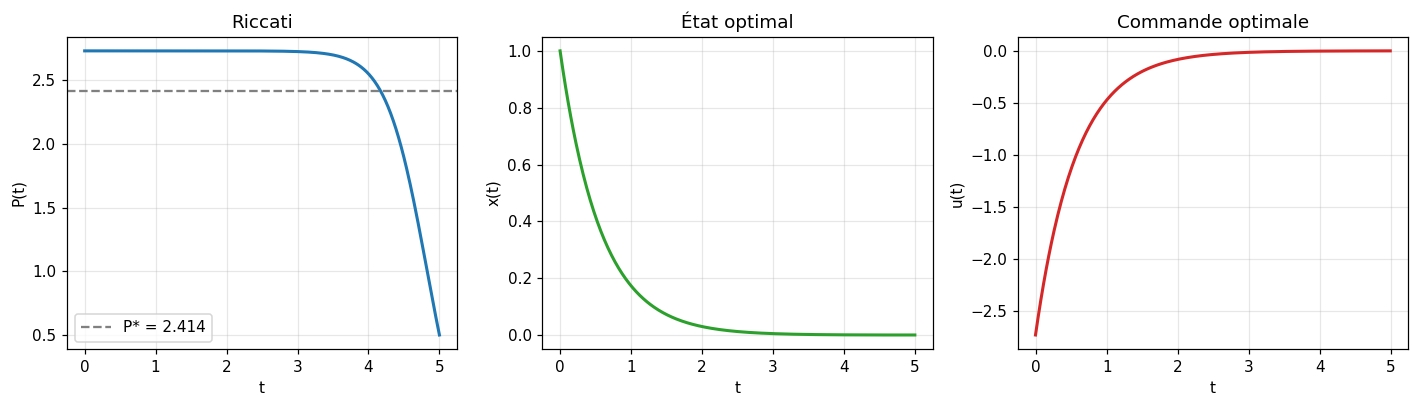

In [2]:
res = opt.pontryagin_lqr(
    a=1.0, b=1.0, q=1.0, r=1.0, s_terminal=0.5,
    x0=1.0, t_horizon=5.0, n_steps=400,
)
ts = np.array(res['time_grid'])
P = np.array(res['riccati'])
state = np.array(res['state'])
control = np.array(res['control'])

P_star = 1.0 + np.sqrt(2.0)
print(f"P(0) numérique  = {P[0]:.4f}")
print(f"P* analytique   = {P_star:.4f}")
print(f"P(T) (terminal) = {P[-1]:.4f}")
print(f"Coût optimal    = {res['cost']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(ts, P, lw=2)
axes[0].axhline(P_star, ls='--', color='gray',
                label=f'P* = {P_star:.3f}')
axes[0].set_xlabel('t'); axes[0].set_ylabel('P(t)')
axes[0].set_title("Riccati"); axes[0].legend()
axes[1].plot(ts, state, lw=2, color='C2')
axes[1].set_xlabel('t'); axes[1].set_ylabel('x(t)')
axes[1].set_title("État optimal")
ts_u = ts[:len(control)]
axes[2].plot(ts_u, control, lw=2, color='C3')
axes[2].set_xlabel('t'); axes[2].set_ylabel('u(t)')
axes[2].set_title("Commande optimale")
fig.tight_layout(); plt.show()


**Résultat attendu.** $P(0) \approx 1 + \sqrt{2}$ ; l'état $x$
décroît rapidement vers $0$ ; la commande est proportionnelle à
$-P(t)\,x(t)/r$.

**Lecture du graphique.** $P(t)$ plate sur $[0, T-\epsilon]$ puis
descend vers $s = 0.5$ ; trajectoires d'état/commande lisses.

**Conclusion.** Le LQR scalaire est validé contre le point fixe
analytique.


## Cellule 2 — Étude paramétrique : sensibilité au coût terminal

**Théorème.** Lorsque $T \to \infty$, $P(0)$ tend vers le point fixe
indépendamment de $s$.

**Équation pivot.** $P^* = (a + \sqrt{a^2 + b^2 q / r}) \cdot r / b^2$.
Pour $a = b = q = r = 1$, $P^* = 1 + \sqrt{2}$.

**Ce que la cellule vérifie.** Sweep sur plusieurs valeurs de $s$ et
de $T$ : $P(0)$ converge vers $P^*$.


s =  0.1 : P(0) à T=10 = 2.7321
s =  0.5 : P(0) à T=10 = 2.7321
s =  2.0 : P(0) à T=10 = 2.7321
s =  5.0 : P(0) à T=10 = 2.7321


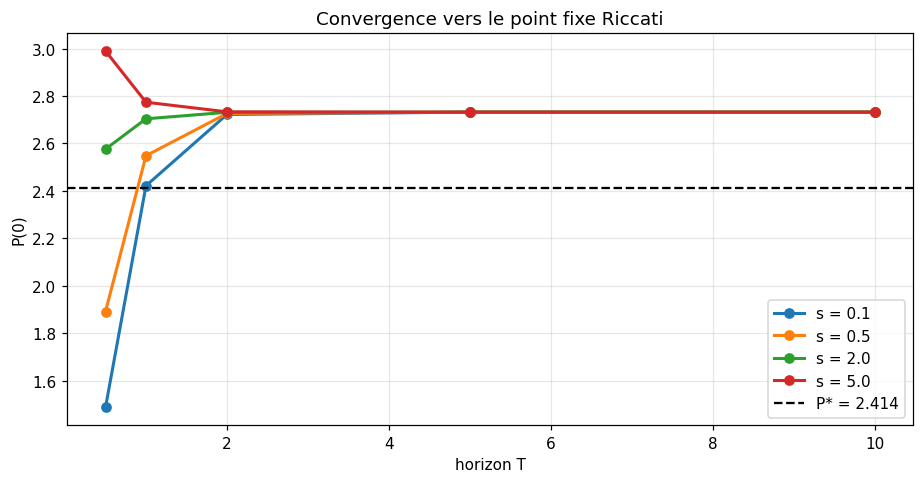

In [3]:
s_values = [0.1, 0.5, 2.0, 5.0]
T_values = [0.5, 1.0, 2.0, 5.0, 10.0]
P_star = 1.0 + np.sqrt(2.0)

fig, ax = plt.subplots()
for s in s_values:
    p0s = []
    for T_ in T_values:
        r = opt.pontryagin_lqr(1.0, 1.0, 1.0, 1.0, s, 1.0, T_, 200)
        p0s.append(r['riccati'][0])
    ax.plot(T_values, p0s, 'o-', lw=2, label=f's = {s}')
    print(f"s = {s:4.1f} : P(0) à T=10 = {p0s[-1]:.4f}")
ax.axhline(P_star, ls='--', color='black',
           label=f'P* = {P_star:.3f}')
ax.set_xlabel('horizon T'); ax.set_ylabel('P(0)')
ax.set_title("Convergence vers le point fixe Riccati")
ax.legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** Toutes les courbes convergent vers
$P^* \approx 2.414$ pour $T$ grand.

**Lecture du graphique.** L'effet du terminal $s$ s'estompe quand $T$
augmente.

**Conclusion.** En horizon long, le coût terminal devient négligeable.


## Cellule 3 — Exemple concret : stabilisation d'un pendule inversé

**Modèle physique.** Pendule inversé linéarisé autour de la verticale
$\ddot\theta = (g/\ell)\theta + (1/m\ell^2) u$.  Pour le mode
sur-amorti $(\dot\theta \equiv 0)$ on retient l'équation scalaire
$\dot\theta = a\theta + bu$ avec $a = g/\ell$, $b = 1/(m\ell^2)$.

**Équation pivot (Riccati).** $P$ vérifie $-\dot P = 2aP - (b^2/r)P^2 + q$.

**Ce que la cellule vérifie.** Le contrôleur LQR ramène l'angle
initial $0.3$ rad vers $0$.


Angle initial : 0.300 rad (17.2°)
Angle final   : 5.955e-25 rad
Effort max    : 6.177


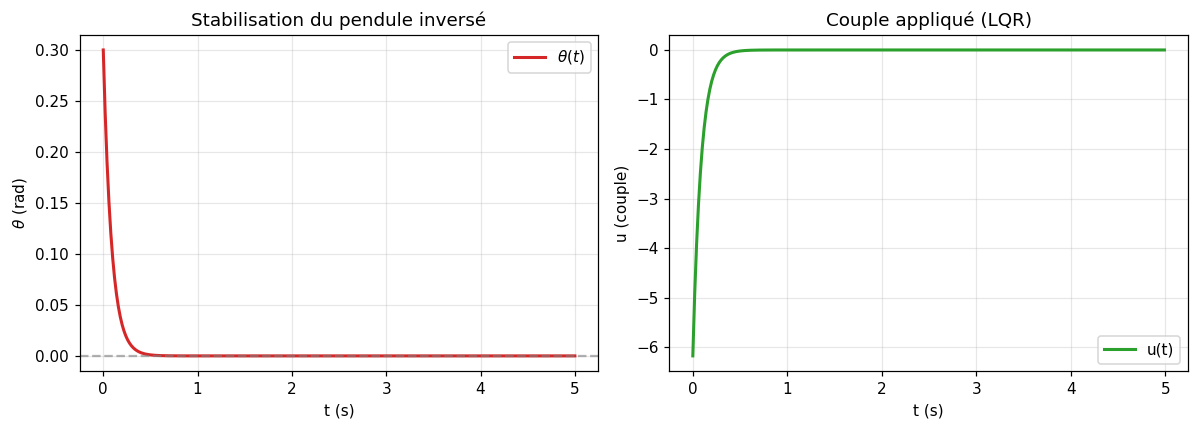

In [4]:
g, ell, m = 9.81, 1.0, 1.0
a, b = g / ell, 1.0 / (m * ell ** 2)
res = opt.pontryagin_lqr(a, b, q=10.0, r=1.0, s_terminal=1.0,
                          x0=0.3, t_horizon=5.0, n_steps=500)
ts = np.array(res['time_grid'])
theta = np.array(res['state'])
u = np.array(res['control'])

print(f"Angle initial : {theta[0]:.3f} rad ({np.degrees(theta[0]):.1f}°)")
print(f"Angle final   : {theta[-1]:.3e} rad")
print(f"Effort max    : {np.abs(u).max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ts, theta, lw=2, color='C3', label=r'$\theta(t)$')
axes[0].axhline(0, ls='--', color='gray', alpha=0.6)
axes[0].set_xlabel('t (s)'); axes[0].set_ylabel(r'$\theta$ (rad)')
axes[0].set_title("Stabilisation du pendule inversé")
axes[0].legend()
ts_u = ts[:len(u)]
axes[1].plot(ts_u, u, lw=2, color='C2', label='u(t)')
axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('u (couple)')
axes[1].set_title("Couple appliqué (LQR)")
axes[1].legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** $\theta \to 0$ rapidement, effort borné.

**Lecture du graphique.** Décroissance exponentielle de l'angle ;
couple initial fort puis amorti.

**Conclusion.** Le primitive transforme un système naturellement
instable ($a = 9.81 > 0$) en système stable, illustration directe
du contrôle optimal.
